# 🇻🇳 Fine-tune ViT5-base cho Tóm Tắt Văn Bản Tiếng Việt

**Mô hình:** `VietAI/vit5-base`  
**Nhiệm vụ:** Abstractive Summarization  
**Yêu cầu:** GPU (T4 hoặc tốt hơn trên Colab)

---
### Nội dung notebook:
1. Cài đặt thư viện
2. Mount Google Drive & Load dữ liệu
3. EDA & Kiểm tra số liệu
4. Tokenization & Dataset
5. Fine-tuning ViT5
6. Đánh giá (ROUGE, BLEU, BERTScore, Number Accuracy, Length Compliance)
7. Inference & Demo
8. Lưu model lên Google Drive

## 1. Cài đặt thư viện

In [ ]:
# Fix dependency versions for Google Colab (Python 3.12)
# Chạy cell này đầu tiên. Sau khi chạy xong, chọn Runtime > Restart runtime, rồi chạy các cell tiếp theo.
!pip uninstall -y -q peft
!pip install -q -U \
    "transformers==4.41.2" \
    "datasets==2.19.2" \
    "accelerate==0.30.1" \
    "evaluate==0.4.2" \
    "sentencepiece==0.2.0" \
    "rouge-score==0.1.2" \
    "bert-score==0.3.13" \
    "sacrebleu==2.4.0" \
    "nltk" \
    "underthesea"

import importlib.metadata as md
for pkg in ["transformers", "datasets", "accelerate", "evaluate", "sentencepiece", "rouge-score", "bert-score", "sacrebleu"]:
    print(pkg, md.version(pkg))

print("\n✅ Đã cài xong dependency. BẮT BUỘC chọn Runtime > Restart runtime trên Colab, sau đó chạy lại từ cell import bên dưới.")


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 whic

In [ ]:
import os, re, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    T5Tokenizer, T5ForConditionalGeneration,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
import evaluate

# Seed cho reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 2. Mount Google Drive & Load dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive đã mount thành công!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive đã mount thành công!


In [ ]:
DATA_DIR   = '/content/drive/MyDrive/NLP_FINAL/DATA'
OUTPUT_DIR = '/content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_df = pd.read_csv(f'{DATA_DIR}/train_for_model.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val_for_model.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test_for_model.csv')

# Đảm bảo tên cột đúng
for df, name in [(train_df,'train'),(val_df,'val'),(test_df,'test')]:
    df.dropna(subset=['original_text','summary'], inplace=True)
    df['original_text'] = df['original_text'].astype(str).str.strip()
    df['summary']       = df['summary'].astype(str).str.strip()
    df.reset_index(drop=True, inplace=True)
    print(f'✅ {name}: {len(df)} mẫu | Cột: {list(df.columns)}')

✅ train: 1244 mẫu | Cột: ['title', 'original_text', 'summary']
✅ val: 156 mẫu | Cột: ['title', 'original_text', 'summary']
✅ test: 156 mẫu | Cột: ['title', 'original_text', 'summary']


## 3. EDA & Kiểm tra số liệu

In [ ]:
def word_count(text):
    return len(str(text).split())

def extract_numbers(text):
    """Trích xuất tất cả số liệu trong văn bản tiếng Việt."""
    text = str(text)
    # Số có đơn vị tiền tệ/phần trăm/đơn vị VN
    pattern = r'\b\d+(?:[.,]\d+)*(?:\s*(?:tỷ|triệu|nghìn|tỉ|%|đồng|USD|VND|kg|km|ha|MW|GW))?\b'
    numbers = re.findall(pattern, text)
    # Lọc bỏ số quá ngắn không có nghĩa (năm dạng 2020, 2024 OK)
    return set(n.strip() for n in numbers if n.strip())

def number_preservation_rate(src, tgt):
    src_nums = extract_numbers(src)
    tgt_nums = extract_numbers(tgt)
    if not src_nums:
        return 1.0, set(), set()
    missing      = src_nums - tgt_nums
    hallucinated = tgt_nums - src_nums
    preserved    = src_nums & tgt_nums
    recall    = len(preserved) / len(src_nums)
    precision = len(preserved) / len(tgt_nums) if tgt_nums else 0.0
    f1 = 2*precision*recall / (precision+recall+1e-9)
    return f1, missing, hallucinated

# Tính stats cho từng tập
for df, name in [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]:
    df['src_wc']   = df['original_text'].apply(word_count)
    df['tgt_wc']   = df['summary'].apply(word_count)
    df['ratio']    = df['tgt_wc'] / df['src_wc']
    df['num_f1']   = df.apply(
        lambda r: number_preservation_rate(r['original_text'], r['summary'])[0], axis=1
    )
    compliant = df['ratio'].between(0.20, 0.25).mean()
    print(f'\n=== {name} ({len(df)} mẫu) ===')
    print(f'  src_wc  : mean={df.src_wc.mean():.0f}, min={df.src_wc.min()}, max={df.src_wc.max()}')
    print(f'  tgt_wc  : mean={df.tgt_wc.mean():.0f}, min={df.tgt_wc.min()}, max={df.tgt_wc.max()}')
    print(f'  ratio   : mean={df.ratio.mean():.3f}, std={df.ratio.std():.3f}')
    print(f'  length_compliance (20-25%): {compliant:.2%}')
    print(f'  number_f1 mean : {df.num_f1.mean():.4f}')
    print(f'  num_f1 < 1.0   : {(df.num_f1 < 1.0).sum()} mẫu')


=== Train (1244 mẫu) ===
  src_wc  : mean=645, min=139, max=3307
  tgt_wc  : mean=150, min=25, max=824
  ratio   : mean=0.230, std=0.014
  length_compliance (20-25%): 95.42%
  number_f1 mean : 0.6664
  num_f1 < 1.0   : 1244 mẫu

=== Val (156 mẫu) ===
  src_wc  : mean=638, min=189, max=2180
  tgt_wc  : mean=148, min=38, max=540
  ratio   : mean=0.230, std=0.014
  length_compliance (20-25%): 94.87%
  number_f1 mean : 0.6599
  num_f1 < 1.0   : 156 mẫu

=== Test (156 mẫu) ===
  src_wc  : mean=616, min=167, max=1600
  tgt_wc  : mean=143, min=36, max=395
  ratio   : mean=0.230, std=0.014
  length_compliance (20-25%): 96.15%
  number_f1 mean : 0.6771
  num_f1 < 1.0   : 156 mẫu


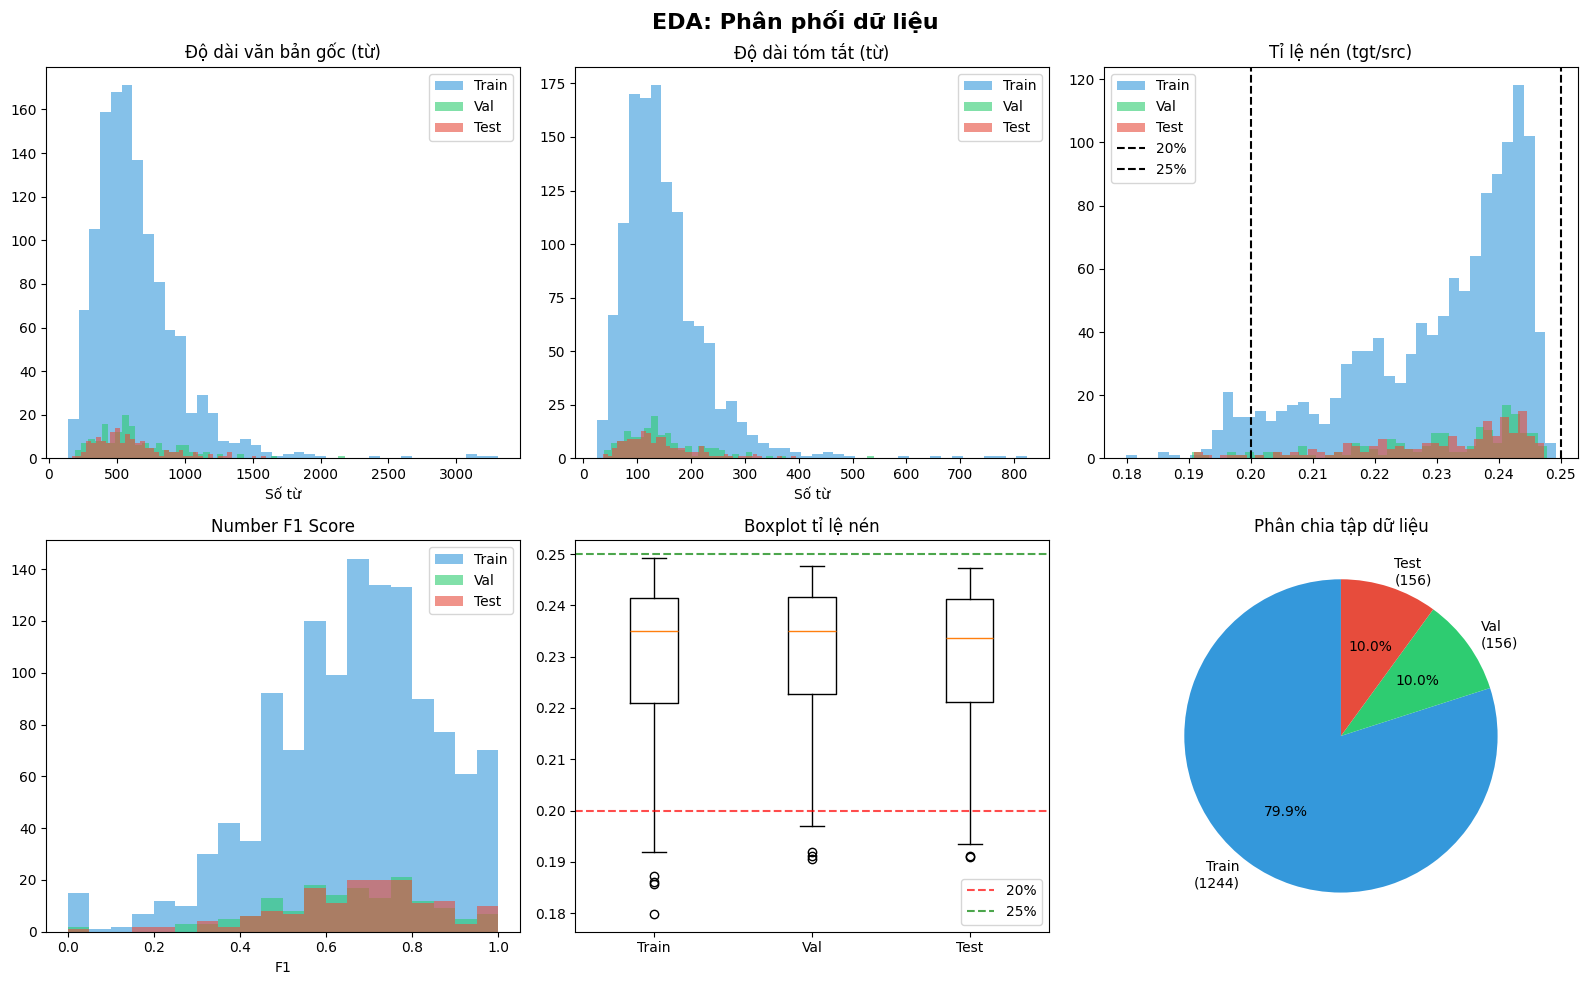

✅ Đã lưu biểu đồ EDA!


In [ ]:
# Visualize phân phối
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA: Phân phối dữ liệu', fontsize=16, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c']
labels = ['Train', 'Val', 'Test']

for i, (df, name, c) in enumerate(zip([train_df,val_df,test_df], labels, colors)):
    # Độ dài văn bản gốc
    axes[0,0].hist(df['src_wc'], bins=40, alpha=0.6, color=c, label=name)
    # Độ dài tóm tắt
    axes[0,1].hist(df['tgt_wc'], bins=40, alpha=0.6, color=c, label=name)
    # Tỉ lệ nén
    axes[0,2].hist(df['ratio'], bins=40, alpha=0.6, color=c, label=name)
    # Number F1
    axes[1,0].hist(df['num_f1'], bins=20, alpha=0.6, color=c, label=name)

axes[0,0].set_title('Độ dài văn bản gốc (từ)'); axes[0,0].set_xlabel('Số từ'); axes[0,0].legend()
axes[0,1].set_title('Độ dài tóm tắt (từ)'); axes[0,1].set_xlabel('Số từ'); axes[0,1].legend()
axes[0,2].set_title('Tỉ lệ nén (tgt/src)'); axes[0,2].axvline(0.20, color='k', ls='--', label='20%')
axes[0,2].axvline(0.25, color='k', ls='--', label='25%'); axes[0,2].legend()
axes[1,0].set_title('Number F1 Score'); axes[1,0].set_xlabel('F1'); axes[1,0].legend()

# Boxplot so sánh
axes[1,1].boxplot([train_df['ratio'], val_df['ratio'], test_df['ratio']], labels=labels)
axes[1,1].axhline(0.20, color='r', ls='--', alpha=0.7, label='20%')
axes[1,1].axhline(0.25, color='g', ls='--', alpha=0.7, label='25%')
axes[1,1].set_title('Boxplot tỉ lệ nén'); axes[1,1].legend()

# Số mẫu mỗi tập
sizes = [len(train_df), len(val_df), len(test_df)]
axes[1,2].pie(sizes, labels=[f'{l}\n({s})' for l,s in zip(labels,sizes)],
              colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,2].set_title('Phân chia tập dữ liệu')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ EDA!')

## 4. Tokenization & Dataset

In [ ]:
MODEL_NAME     = 'VietAI/vit5-base'
MAX_INPUT_LEN  = 1024
MAX_TARGET_LEN = 288
PREFIX         = 'summarize: '   # T5-style prefix

print(f'⏳ Đang tải tokenizer {MODEL_NAME}...')
# Dùng T5Tokenizer với legacy=True để tránh lỗi fast tokenizer/tokenizers trên Colab Python 3.12
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, legacy=True)
print(f'✅ Vocab size: {tokenizer.vocab_size:,}')
print(f'✅ Model max length: {tokenizer.model_max_length}')


⏳ Đang tải tokenizer VietAI/vit5-base...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Vocab size: 36,000
✅ Model max length: 1000000000000000019884624838656


## 4.1. Lọc lỗi số liệu và giới hạn `original_text` ≤ 1056 token

Cell này chạy sau khi đã load tokenizer. Mục tiêu: phát hiện các mẫu summary có số liệu không tồn tại trong original_text, lưu file lỗi để kiểm tra thủ công, và chỉ giữ các mẫu có input không vượt `MAX_INPUT_LEN = 1056` token trước khi fine-tune.


In [ ]:
# ============================================================
# LỌC LỖI SỐ LIỆU + GIỚI HẠN TOKEN SOURCE <= 1056
# ============================================================
from collections import Counter
import unicodedata

MAX_INPUT_LEN = 1056  # Yêu cầu: original_text sau khi cộng PREFIX không vượt quá 1056 token

# Chọn cách lọc số liệu:
# - 'no_hallucinated': giữ mẫu nếu mọi số trong summary đều có trong original_text.
#   Đây là chế độ khuyến nghị, vì summary không nhất thiết phải giữ TẤT CẢ số phụ trong bài gốc.
# - 'strict_equal': giữ mẫu nếu tập số trong summary khớp hoàn toàn với tập số trong original_text.
#   Chế độ này rất gắt, thường sẽ loại quá nhiều mẫu.
NUMBER_FILTER_MODE = 'no_hallucinated'

NUMBER_PATTERN = re.compile(
    r"""(?ix)
    (?<![\w])
    (?:
        \d{1,3}(?:[.,]\d{3})+(?:[.,]\d+)?   # 1.234 / 1,234 / 1.234,56
        |\d+(?:[.,]\d+)?                     # 12 / 12,5 / 12.5
    )
    (?:\s*(?:
        %|tỷ\s*đồng|tỉ\s*đồng|triệu\s*đồng|nghìn\s*đồng|đồng|
        usd|vnd|eur|km|kg|ha|m2|m²|mw|gw|
        người|doanh\s*nghiệp|cổ\s*phiếu|tháng|năm|ngày
    ))?
    (?![\w])
    """
)

def normalize_number_expr(x):
    """Chuẩn hóa biểu thức số để so khớp ổn định hơn."""
    x = unicodedata.normalize('NFKC', str(x)).lower().strip()
    x = re.sub(r'\s+', ' ', x)
    x = x.replace('tỉ', 'tỷ')
    x = x.replace('m²', 'm2')

    # Tách phần số và phần đơn vị nếu có
    m = re.match(r'^([0-9][0-9.,]*)(.*)$', x)
    if not m:
        return x.replace(' ', '')

    num, unit = m.group(1), m.group(2).strip()

    # Chuẩn hóa dấu phân cách nghìn/thập phân thường gặp trong tiếng Việt
    # 1.234.567 -> 1234567
    if re.fullmatch(r'\d{1,3}(?:\.\d{3})+', num):
        num = num.replace('.', '')
    # 1,234,567 -> 1234567
    elif re.fullmatch(r'\d{1,3}(?:,\d{3})+', num):
        num = num.replace(',', '')
    # 12,5 -> 12.5
    elif ',' in num and '.' not in num:
        num = num.replace(',', '.')

    unit = unit.replace(' ', '')
    return f'{num}{unit}'

def extract_numbers_norm(text):
    """Trích xuất số liệu và trả về list đã chuẩn hóa."""
    text = unicodedata.normalize('NFKC', str(text))
    nums = NUMBER_PATTERN.findall(text)
    return [normalize_number_expr(n) for n in nums if str(n).strip()]

def number_quality(src, tgt):
    """
    Đánh giá khớp số liệu giữa original_text và summary bằng Counter.
    - hallucinated: số có trong summary nhưng không có trong original_text => lỗi nghiêm trọng.
    - missing: số có trong original_text nhưng không có trong summary => cần xem lại, nhưng không phải lúc nào cũng sai
      vì summary có thể bỏ số phụ.
    """
    src_c = Counter(extract_numbers_norm(src))
    tgt_c = Counter(extract_numbers_norm(tgt))

    preserved_c    = src_c & tgt_c
    missing_c      = src_c - tgt_c
    hallucinated_c = tgt_c - src_c

    precision = sum(preserved_c.values()) / sum(tgt_c.values()) if sum(tgt_c.values()) else 1.0
    recall    = sum(preserved_c.values()) / sum(src_c.values()) if sum(src_c.values()) else 1.0
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    return {
        'num_precision': precision,
        'num_recall': recall,
        'num_f1_fixed': f1,
        'num_missing_count': sum(missing_c.values()),
        'num_hallucinated_count': sum(hallucinated_c.values()),
        'missing_numbers': ', '.join(missing_c.elements()),
        'hallucinated_numbers': ', '.join(hallucinated_c.elements())
    }

def source_token_len(text):
    """Tính số token thật của source sau khi cộng prefix, không truncation."""
    return len(tokenizer(
        PREFIX + str(text),
        add_special_tokens=True,
        truncation=False
    )['input_ids'])

def target_token_len(text):
    """Tính số token thật của summary, không truncation."""
    return len(tokenizer(
        str(text),
        add_special_tokens=True,
        truncation=False
    )['input_ids'])

def clean_by_numbers_and_tokens(df, split_name):
    df = df.copy().reset_index(drop=True)

    # Tính lại độ dài token bằng tokenizer thật của ViT5
    df['src_token_len'] = df['original_text'].apply(source_token_len)
    df['tgt_token_len'] = df['summary'].apply(target_token_len)

    # Tính chất lượng số liệu
    num_info = df.apply(
        lambda r: pd.Series(number_quality(r['original_text'], r['summary'])),
        axis=1
    )
    df = pd.concat([df, num_info], axis=1)

    # Điều kiện token: không để original_text vượt quá 1056 token
    token_ok = df['src_token_len'] <= MAX_INPUT_LEN

    # Điều kiện số liệu
    if NUMBER_FILTER_MODE == 'strict_equal':
        number_ok = (df['num_missing_count'] == 0) & (df['num_hallucinated_count'] == 0)
    else:
        # Khuyến nghị: loại các summary có số tự sinh/không tồn tại trong văn bản gốc
        number_ok = df['num_hallucinated_count'] == 0

    keep_mask = token_ok & number_ok

    # Lưu các mẫu bị loại để bạn kiểm tra / sửa thủ công
    bad_token_df  = df[~token_ok].copy()
    bad_number_df = df[~number_ok].copy()
    removed_df    = df[~keep_mask].copy()
    kept_df       = df[keep_mask].copy().reset_index(drop=True)

    bad_token_df.to_csv(f'{OUTPUT_DIR}/{split_name}_bad_over_{MAX_INPUT_LEN}_tokens.csv', index=False, encoding='utf-8-sig')
    bad_number_df.to_csv(f'{OUTPUT_DIR}/{split_name}_bad_number_mismatch.csv', index=False, encoding='utf-8-sig')
    removed_df.to_csv(f'{OUTPUT_DIR}/{split_name}_removed_by_cleaning.csv', index=False, encoding='utf-8-sig')

    print(f'=== CLEAN {split_name.upper()} ===')
    print(f'Input samples                 : {len(df)}')
    print(f'Source token mean / max       : {df.src_token_len.mean():.0f} / {df.src_token_len.max()}')
    print(f'Over {MAX_INPUT_LEN} src token       : {(~token_ok).sum()}')
    print(f'Number hallucination samples  : {(df.num_hallucinated_count > 0).sum()}')
    print(f'Removed total                 : {len(removed_df)}')
    print(f'Kept samples                  : {len(kept_df)}')
    print(f'Saved bad files to            : {OUTPUT_DIR}')

    return kept_df, removed_df

train_df, train_removed_df = clean_by_numbers_and_tokens(train_df, 'train')
val_df,   val_removed_df   = clean_by_numbers_and_tokens(val_df,   'val')
test_df,  test_removed_df  = clean_by_numbers_and_tokens(test_df,  'test')

# Cập nhật lại thống kê word/ratio sau khi lọc để các cell sau dùng đúng dữ liệu mới
for df in [train_df, val_df, test_df]:
    df['src_wc'] = df['original_text'].apply(word_count)
    df['tgt_wc'] = df['summary'].apply(word_count)
    df['ratio']  = df['tgt_wc'] / df['src_wc']

print('✅ Đã lọc dữ liệu xong. Các dataset dùng để train/val/test đã được cập nhật.')
print(f'✅ MAX_INPUT_LEN hiện tại = {MAX_INPUT_LEN}')


=== CLEAN TRAIN ===
Input samples                 : 1244
Source token mean / max       : 790 / 3840
Over 1056 src token       : 215
Number hallucination samples  : 70
Removed total                 : 269
Kept samples                  : 975
Saved bad files to            : /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT
=== CLEAN VAL ===
Input samples                 : 156
Source token mean / max       : 783 / 2607
Over 1056 src token       : 30
Number hallucination samples  : 7
Removed total                 : 36
Kept samples                  : 120
Saved bad files to            : /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT
=== CLEAN TEST ===
Input samples                 : 156
Source token mean / max       : 758 / 1962
Over 1056 src token       : 27
Number hallucination samples  : 17
Removed total                 : 42
Kept samples                  : 114
Saved bad files to            : /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT
✅ Đã lọc dữ liệu xong. Các dataset dùng để train/val/test đã đ

In [ ]:
# Phân tích token length để chọn max_length hợp lý
sample_src = train_df['original_text'].sample(min(200, len(train_df)), random_state=SEED)
sample_tgt = train_df['summary'].sample(min(200, len(train_df)), random_state=SEED)

src_token_lens = [len(tokenizer.encode(t)) for t in sample_src]
tgt_token_lens = [len(tokenizer.encode(t)) for t in sample_tgt]

print('=== Token Length Analysis ===')
print(f'SOURCE  - mean:{np.mean(src_token_lens):.0f}, 95p:{np.percentile(src_token_lens,95):.0f}, max:{max(src_token_lens)}')
print(f'TARGET  - mean:{np.mean(tgt_token_lens):.0f}, 95p:{np.percentile(tgt_token_lens,95):.0f}, max:{max(tgt_token_lens)}')
print(f'\nSetting: MAX_INPUT={MAX_INPUT_LEN}, MAX_TARGET={MAX_TARGET_LEN}')
src_truncated = sum(1 for l in src_token_lens if l > MAX_INPUT_LEN)
tgt_truncated = sum(1 for l in tgt_token_lens if l > MAX_TARGET_LEN)
print(f'Truncated src: {src_truncated}/{len(src_token_lens)} ({src_truncated/len(src_token_lens):.1%})')
print(f'Truncated tgt: {tgt_truncated}/{len(tgt_token_lens)} ({tgt_truncated/len(tgt_token_lens):.1%})')

=== Token Length Analysis ===
SOURCE  - mean:651, 95p:996, max:1044
TARGET  - mean:159, 95p:250, max:271

Setting: MAX_INPUT=1056, MAX_TARGET=288
Truncated src: 0/200 (0.0%)
Truncated tgt: 0/200 (0.0%)


In [ ]:
class VietnameseSumDataset(Dataset):
    def __init__(self, df, tokenizer, max_input=1024, max_target=256, prefix='summarize: '):
        self.data       = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_input  = max_input
        self.max_target = max_target
        self.prefix     = prefix

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        source = self.prefix + str(row['original_text'])
        target = str(row['summary'])

        # Tokenize source
        model_inputs = self.tokenizer(
            source,
            max_length=self.max_input,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        # Tokenize target
        with self.tokenizer.as_target_tokenizer():
            labels = self.tokenizer(
                target,
                max_length=self.max_target,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )

        label_ids = labels['input_ids'].squeeze().clone()
        # Thay pad_token_id bằng -100 để bỏ qua trong loss
        label_ids[label_ids == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids':      model_inputs['input_ids'].squeeze(),
            'attention_mask': model_inputs['attention_mask'].squeeze(),
            'labels':         label_ids
        }

train_dataset = VietnameseSumDataset(train_df, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN, PREFIX)
val_dataset   = VietnameseSumDataset(val_df,   tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN, PREFIX)
test_dataset  = VietnameseSumDataset(test_df,  tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN, PREFIX)

print(f'✅ Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

# Kiểm tra 1 sample
sample = train_dataset[0]
print(f'   input_ids shape : {sample["input_ids"].shape}')
print(f'   labels shape    : {sample["labels"].shape}')

✅ Train: 975 | Val: 120 | Test: 114
   input_ids shape : torch.Size([1056])
   labels shape    : torch.Size([288])


## 5. Fine-tuning ViT5

In [ ]:
# Load model
print(f'⏳ Đang tải model {MODEL_NAME}...')
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model loaded!')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')

⏳ Đang tải model VietAI/vit5-base...


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/904M [00:00<?, ?B/s]

✅ Model loaded!
   Total params    : 225,950,976
   Trainable params: 225,950,976


In [ ]:
# Compute metrics cho Trainer
rouge_metric = evaluate.load('rouge')

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Decode predictions
    if isinstance(preds, tuple):
        preds = preds[0]
    preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Chuẩn hóa
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge_metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=False
    )
    result = {k: round(v * 100, 4) for k, v in result.items()}

    # Độ dài trung bình
    prediction_lens = [len(p.split()) for p in decoded_preds]
    result['gen_len'] = round(np.mean(prediction_lens), 2)

    return result

In [ ]:
# ============================================================
# HYPERPARAMETERS - cấu hình cuối sau lọc còn khoảng 975 mẫu train
# Bài toán: tóm tắt tiếng Việt, giữ số liệu, độ dài 20-25%
# ============================================================
BATCH_SIZE      = 4       # Nếu OOM: đổi thành 2
GRAD_ACCUM      = 4       # Effective batch = 4 * 4 = 16. Nếu BATCH_SIZE=2 thì đổi GRAD_ACCUM=8
NUM_EPOCHS      = 6       # Dataset nhỏ, tránh train quá lâu/overfit
LEARNING_RATE   = 3e-5    # An toàn hơn cho bài yêu cầu giữ số liệu chính xác
WARMUP_STEPS    = 35      # Khoảng 10% tổng step với ~975 mẫu train, effective batch 16, 6 epoch
WEIGHT_DECAY    = 0.01

# Generation mặc định khi Trainer eval; phần test cuối vẫn dùng dynamic length theo từng văn bản
NUM_BEAMS        = 4
LENGTH_PENALTY   = 1.25   # Khuyến khích đủ dài nhưng hạn chế lan man/thêm số lạ
NO_REPEAT_NGRAM  = 3
# ============================================================

CHECKPOINT_DIR = f'{OUTPUT_DIR}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Tính tham khảo min/max gen length theo avg src length.
# Lưu ý: phần generate/test cuối dùng dynamic length riêng từng original_text, không phụ thuộc hoàn toàn vào các giá trị trung bình này.
avg_src_wc     = int(train_df['src_wc'].mean())
MIN_GEN_TOKENS = int(avg_src_wc * 0.18 * 1.3)  # ~18% để có buffer
MAX_GEN_TOKENS = min(MAX_TARGET_LEN, int(avg_src_wc * 0.27 * 1.3))  # không vượt MAX_TARGET_LEN
print(f'avg_src_wc={avg_src_wc} → min_gen={MIN_GEN_TOKENS}, max_gen={MAX_GEN_TOKENS}')

training_args = Seq2SeqTrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # Training
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type='cosine',
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    # Generation / Evaluation
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,
    generation_num_beams=NUM_BEAMS,

    # Logging / Checkpoint
    logging_dir=f'{OUTPUT_DIR}/logs',
    logging_steps=25,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='rouge2',
    greater_is_better=True,
    report_to='none',
    seed=SEED
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

import math
effective_batch = BATCH_SIZE * GRAD_ACCUM
steps_per_epoch = math.ceil(len(train_dataset) / effective_batch)
total_steps = steps_per_epoch * NUM_EPOCHS

print('✅ Trainer đã khởi tạo xong!')
print(f'   Train samples        : {len(train_dataset)}')
print(f'   Effective batch size : {effective_batch}')
print(f'   Steps/epoch          : {steps_per_epoch}')
print(f'   Total training steps : {total_steps}')
print(f'   Warmup steps         : {WARMUP_STEPS} ({WARMUP_STEPS / max(total_steps, 1):.1%})')
print(f'   MAX_INPUT_LEN        : {MAX_INPUT_LEN}')
print(f'   MAX_TARGET_LEN       : {MAX_TARGET_LEN}')


avg_src_wc=534 → min_gen=124, max_gen=187
✅ Trainer đã khởi tạo xong!
   Train samples        : 975
   Effective batch size : 16
   Steps/epoch          : 61
   Total training steps : 366
   Warmup steps         : 35 (9.6%)
   MAX_INPUT_LEN        : 1056
   MAX_TARGET_LEN       : 288


In [ ]:
# ========================
# BẮT ĐẦU TRAINING / RESUME TỰ ĐỘNG NẾU COLAB BỊ NGẮT
# Nếu checkpoint lỗi do PyTorch 2.6 thì tự động train lại từ đầu
# ========================
import os, glob, re, shutil

def get_latest_checkpoint(output_dir):
    checkpoints = glob.glob(os.path.join(output_dir, "checkpoint-*"))
    if len(checkpoints) == 0:
        return None

    def checkpoint_step(path):
        m = re.search(r"checkpoint-(\d+)$", path)
        return int(m.group(1)) if m else -1

    checkpoints = sorted(checkpoints, key=checkpoint_step)
    return checkpoints[-1]

latest_checkpoint = get_latest_checkpoint(CHECKPOINT_DIR)

print('🚀 Bắt đầu fine-tune ViT5...')
print(f'📁 Checkpoint dir: {CHECKPOINT_DIR}')

try:
    if latest_checkpoint is not None:
        print(f'✅ Tìm thấy checkpoint mới nhất: {latest_checkpoint}')
        print('➡️  Thử tiếp tục train từ checkpoint này.')
        train_result = trainer.train(resume_from_checkpoint=latest_checkpoint)
    else:
        print('ℹ️  Chưa có checkpoint cũ. Train từ đầu.')
        train_result = trainer.train()

except Exception as e:
    print('⚠️ Resume checkpoint bị lỗi.')
    print('Lỗi:', type(e).__name__, str(e)[:500])
    print('➡️ Xóa checkpoint cũ và train lại từ đầu.')

    if os.path.exists(CHECKPOINT_DIR):
        shutil.rmtree(CHECKPOINT_DIR)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    train_result = trainer.train()

# Lưu kết quả training
print('\n📊 Kết quả training:')
print(train_result.metrics)

# Lưu model tốt nhất
best_model_path = f'{OUTPUT_DIR}/best_model'
trainer.save_model(best_model_path)
tokenizer.save_pretrained(best_model_path)

print(f'\n✅ Model tốt nhất đã lưu tại: {best_model_path}')

🚀 Bắt đầu fine-tune ViT5...
📁 Checkpoint dir: /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/checkpoints
✅ Tìm thấy checkpoint mới nhất: /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/checkpoints/checkpoint-366
➡️  Thử tiếp tục train từ checkpoint này.


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_18056/1257171331.py", line 28, in <cell line: 0>
    train_result = trainer.train(resume_from_checkpoint=latest_checkpoint)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/trainer.py", line 1885, in train
    return inner_training_loop(
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/trainer.py", line 2070, in _inner_training_loop
    self._load_optimizer_and_scheduler(resume_from_checkpoint)
  File "/usr/local/lib/python3.12/dist-packages/transformers/trainer.py", line 3017, in _load_optimizer_and_scheduler
    torch.load(os.path.join(checkpoint, OPTIMIZER_NAME), map_location=map_location)
  File "/usr/local/lib/python3.12/dist-packages/tor

TypeError: object of type 'NoneType' has no len()

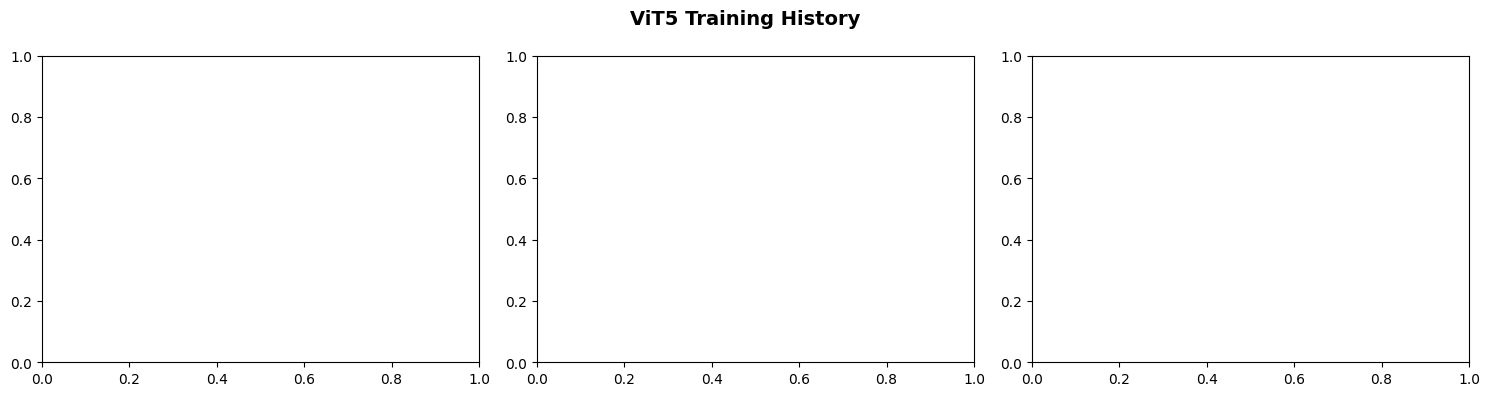

In [ ]:
# Plot training loss history
log_history = trainer.state.log_history

train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
eval_entries = [(e['epoch'], e.get('eval_rouge2',0), e.get('eval_loss',0))
                for e in log_history if 'eval_rouge2' in e]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ViT5 Training History', fontsize=14, fontweight='bold')

if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, '#3498db', lw=1.5)
    axes[0].set_title('Training Loss'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

if eval_entries:
    epochs, r2s, eval_losses = zip(*eval_entries)
    axes[1].plot(epochs, r2s, '#2ecc71', marker='o', lw=2)
    axes[1].set_title('Validation ROUGE-2'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROUGE-2')
    axes[1].grid(alpha=0.3)
    axes[2].plot(epochs, eval_losses, '#e74c3c', marker='s', lw=2)
    axes[2].set_title('Validation Loss'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
    axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Đánh giá toàn diện trên tập Test

In [ ]:
from bert_score import score as bert_score_fn
import sacrebleu

# Load model tốt nhất
best_model_path = f'{OUTPUT_DIR}/best_model'
eval_tokenizer  = T5Tokenizer.from_pretrained(best_model_path, legacy=True)
eval_model      = T5ForConditionalGeneration.from_pretrained(best_model_path).to(device)
eval_model.eval()
print('✅ Model đã load để đánh giá!')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ Model đã load để đánh giá!


In [ ]:
def generate_summary_constrained(text, model, tokenizer, src_word_count,
                                  ratio_min=0.20, ratio_max=0.25,
                                  num_beams=4, length_penalty=1.5,
                                  prefix='summarize: '):
    """
    Sinh tóm tắt với ràng buộc độ dài 20-25% so với văn bản gốc.
    """
    min_words  = int(src_word_count * ratio_min)
    max_words  = int(src_word_count * ratio_max)
    # Token ~ words * 1.3 cho tiếng Việt
    min_tokens = max(10, int(min_words * 1.3))
    max_tokens = max(min_tokens + 10, int(max_words * 1.3))

    inputs = tokenizer(
        prefix + text,
        return_tensors='pt',
        max_length=MAX_INPUT_LEN,
        truncation=True
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            num_beams=num_beams,
            min_length=min_tokens,
            max_length=max_tokens,
            length_penalty=length_penalty,
            no_repeat_ngram_size=3,
            early_stopping=True,
            forced_eos_token_id=tokenizer.eos_token_id
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary.strip()


def postprocess_check_numbers(original, summary):
    """
    Kiểm tra số liệu sau generation theo tiêu chí mới:
    - Số trong summary phải xuất hiện trong original_text.
    - Thiếu số trong original_text không bị xem là lỗi.
    Trả về: summary, missing_numbers, hallucinated_numbers.
    """
    acc, missing, hallucinated = number_accuracy_rate(original, summary)
    return summary, missing, hallucinated


print('✅ Functions đã định nghĩa!')


✅ Functions đã định nghĩa!


In [ ]:
# ============================================================
# GENERATE trên toàn bộ tập test
# ============================================================
print(f'⏳ Đang generate {len(test_df)} tóm tắt...')

predictions = []
references  = test_df['summary'].tolist()
sources     = test_df['original_text'].tolist()

for i, (src, ref) in enumerate(zip(sources, references)):
    src_wc = word_count(src)
    pred   = generate_summary_constrained(
        src, eval_model, eval_tokenizer, src_wc
    )
    predictions.append(pred)
    if (i+1) % 20 == 0:
        print(f'  [{i+1}/{len(test_df)}] done')

print(f'✅ Đã generate xong {len(predictions)} tóm tắt!')

⏳ Đang generate 114 tóm tắt...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# HÀM KIỂM TRA ĐỘ CHÍNH XÁC SỐ LIỆU
# Number Accuracy:
# - Chỉ xét các số xuất hiện trong summary/prediction.
# - Nếu số trong summary có trong original_text => đúng.
# - Nếu summary thiếu số từ original_text => KHÔNG phạt.
# - Chỉ phạt khi summary sinh số không có trong original_text.
# ============================================================

import re

def extract_numbers(text):
    """
    Trích xuất số liệu từ văn bản:
    - Số nguyên: 2024, 1000
    - Số thập phân: 10.5, 10,5
    - Phần trăm: 20%
    - Ngày tháng: 12/4, 12/4/2024
    """
    text = str(text)

    pattern = r"""
        \d{1,2}/\d{1,2}(?:/\d{2,4})?   # ngày dạng 12/4 hoặc 12/4/2024
        |
        \d+(?:[.,]\d+)*%?               # số, số thập phân, phần trăm
    """

    nums = re.findall(pattern, text, flags=re.VERBOSE)

    # Chuẩn hóa khoảng trắng
    nums = [n.strip() for n in nums if n.strip()]

    return set(nums)


def number_accuracy_rate(src, tgt):
    """
    Đo độ chính xác số liệu theo tiêu chí:
    - src: original_text
    - tgt: summary/prediction

    Nếu tất cả số trong summary đều xuất hiện trong original_text:
        accuracy = 1.0

    Nếu summary sinh ra số không có trong original_text:
        accuracy < 1.0

    Thiếu số trong original_text không bị phạt.
    """
    src_nums = extract_numbers(src)
    tgt_nums = extract_numbers(tgt)

    # Nếu summary không sinh số nào thì không có số sai
    if len(tgt_nums) == 0:
        return 1.0, set(), set()

    correct_nums = tgt_nums & src_nums
    hallucinated = tgt_nums - src_nums
    missing = src_nums - tgt_nums  # chỉ lưu để tham khảo, không dùng để tính điểm

    accuracy = len(correct_nums) / len(tgt_nums)

    return accuracy, missing, hallucinated


print("✅ Đã định nghĩa xong hàm number_accuracy_rate.")

✅ Đã định nghĩa xong hàm number_accuracy_rate.


In [ ]:
# ============================================================
# TÍNH TẤT CẢ METRICS
# Number Accuracy mới:
# - Chỉ phạt số sinh ra trong summary nhưng không có trong original_text.
# - Thiếu số trong original_text không bị phạt.
# ============================================================

print('📊 Đang tính ROUGE...')
rouge = evaluate.load('rouge')
rouge_results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=False
)

print('📊 Đang tính BLEU...')
bleu_result = sacrebleu.corpus_bleu(predictions, [references])

print('📊 Đang tính BERTScore (có thể mất vài phút)...')
P, R, F1 = bert_score_fn(
    predictions, references,
    lang='vi',
    model_type='xlm-roberta-base',
    verbose=False
)

print('📊 Đang tính Number Accuracy & Length Compliance...')
num_accuracy_scores = []
length_ok = []
hallucinated_counts = []

for pred, src in zip(predictions, sources):
    src_wc  = word_count(src)
    pred_wc = word_count(pred)
    ratio   = pred_wc / src_wc if src_wc > 0 else 0
    length_ok.append(0.20 <= ratio <= 0.25)

    acc, missing, hallucinated = number_accuracy_rate(src, pred)
    num_accuracy_scores.append(acc)
    hallucinated_counts.append(len(hallucinated))

# ============================================================
# IN KẾT QUẢ
# ============================================================
print('\n' + '='*55)
print('        EVALUATION RESULTS — ViT5-base')
print('='*55)
print(f"  ROUGE-1          : {rouge_results['rouge1']*100:.2f}")
print(f"  ROUGE-2          : {rouge_results['rouge2']*100:.2f}")
print(f"  ROUGE-L          : {rouge_results['rougeL']*100:.2f}")
print(f"  BLEU             : {bleu_result.score:.2f}")
print(f"  BERTScore F1     : {F1.mean().item()*100:.2f}")
print(f"  Number Accuracy  : {np.mean(num_accuracy_scores)*100:.2f}")
print(f"  Length Compliance: {np.mean(length_ok)*100:.2f}%")
print(f"  Avg wrong nums   : {np.mean(hallucinated_counts):.2f} per sample")
print('='*55)

# Lưu kết quả
eval_results = {
    'model':              'VietAI/vit5-base',
    'ROUGE-1':            round(rouge_results['rouge1']*100, 4),
    'ROUGE-2':            round(rouge_results['rouge2']*100, 4),
    'ROUGE-L':            round(rouge_results['rougeL']*100, 4),
    'BLEU':               round(bleu_result.score, 4),
    'BERTScore-F1':       round(F1.mean().item()*100, 4),
    'Number-Accuracy':    round(np.mean(num_accuracy_scores)*100, 4),
    'Length-Compliance':  round(np.mean(length_ok)*100, 4),
    'Avg-Wrong-Numbers':  round(np.mean(hallucinated_counts), 4)
}

with open(f'{OUTPUT_DIR}/eval_results.json', 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2)
print(f'\n✅ Kết quả đã lưu tại {OUTPUT_DIR}/eval_results.json')


📊 Đang tính ROUGE...
📊 Đang tính BLEU...
📊 Đang tính BERTScore (có thể mất vài phút)...
📊 Đang tính Number Accuracy & Length Compliance...

        EVALUATION RESULTS — ViT5-base
  ROUGE-1          : 77.98
  ROUGE-2          : 56.17
  ROUGE-L          : 57.46
  BLEU             : 48.63
  BERTScore F1     : 91.37
  Number Accuracy  : 97.16
  Length Compliance: 63.16%
  Avg wrong nums   : 0.26 per sample

✅ Kết quả đã lưu tại /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/eval_results.json


In [ ]:
# Lưu predictions ra file để so sánh sau
results_df = pd.DataFrame({
    'original_text':     sources,
    'reference':         references,
    'prediction':        predictions,
    'src_wc':            [word_count(s) for s in sources],
    'pred_wc':           [word_count(p) for p in predictions],
    'ref_wc':            [word_count(r) for r in references],
    'ratio':             [word_count(p)/word_count(s) if word_count(s)>0 else 0
                          for p,s in zip(predictions,sources)],
    'number_accuracy':   num_accuracy_scores,
    'wrong_num_count':   hallucinated_counts,
    'length_ok':         length_ok
})
results_df.to_csv(f'{OUTPUT_DIR}/test_predictions.csv', index=False, encoding='utf-8-sig')
print(f'✅ Predictions đã lưu!')

# Phân tích lỗi: chỉ xem các mẫu có số liệu sai/ảo giác
bad_num_samples = results_df[results_df['number_accuracy'] < 1.0]
print(f'\n⚠️  Mẫu có số liệu sai/ảo giác: {len(bad_num_samples)} / {len(results_df)}')

if len(bad_num_samples) > 0:
    print('\nVí dụ mẫu sinh số không có trong văn bản gốc:')
    for _, row in bad_num_samples.head(3).iterrows():
        acc, missing, hallucinated = number_accuracy_rate(
            row['original_text'],
            row['prediction']
        )
        print(f'  SRC             : {row["original_text"][:150]}...')
        print(f'  PRED            : {row["prediction"][:150]}...')
        print(f'  REF             : {row["reference"][:150]}...')
        print(f'  Number Accuracy : {acc:.3f}')
        print(f'  Wrong numbers   : {hallucinated}\n')


✅ Predictions đã lưu!

⚠️  Mẫu có số liệu sai/ảo giác: 18 / 114

Ví dụ mẫu sinh số không có trong văn bản gốc:
  SRC             : Tiêu đề: Lệ phí hàng không, hàng hải dự kiến được miễn đến cuối năm
Nội dung: Đối với hàng hải, các khoản phí được miễn liên quan đến bảo đảm hàng hải...
  PRED            : Lệ phí hàng không, hàng hải dự kiến được miễn đến cuối năm. Cơ quan này ước tính đề xuất miễn lệ phí có thể giảm thu ngân sách nhà nước khoảng 3.553 t...
  REF             : Lệ phí hàng không, hàng hải dự kiến được miễn đến cuối năm. Đối với hàng hải, các khoản phí được miễn liên quan đến bảo đảm hàng hải, sử dụng vị trí n...
  Number Accuracy : 0.800
  Wrong numbers   : {'30'}

  SRC             : Tiêu đề: TPBank thải 0,87 tấn CO2e trên một tỷ đồng doanh thu
Nội dung: Chia sẻ về câu chuyện phát triển bền vững tại Diễn đàn ESG Việt Nam 2025 chiều...
  PRED            : TPBank thải 0,87 tấn CO2e trên một tỷ đồng doanh thu. Chia sẻ về câu chuyện phát triển bền vững tại Diễn đàn ESG Việt N

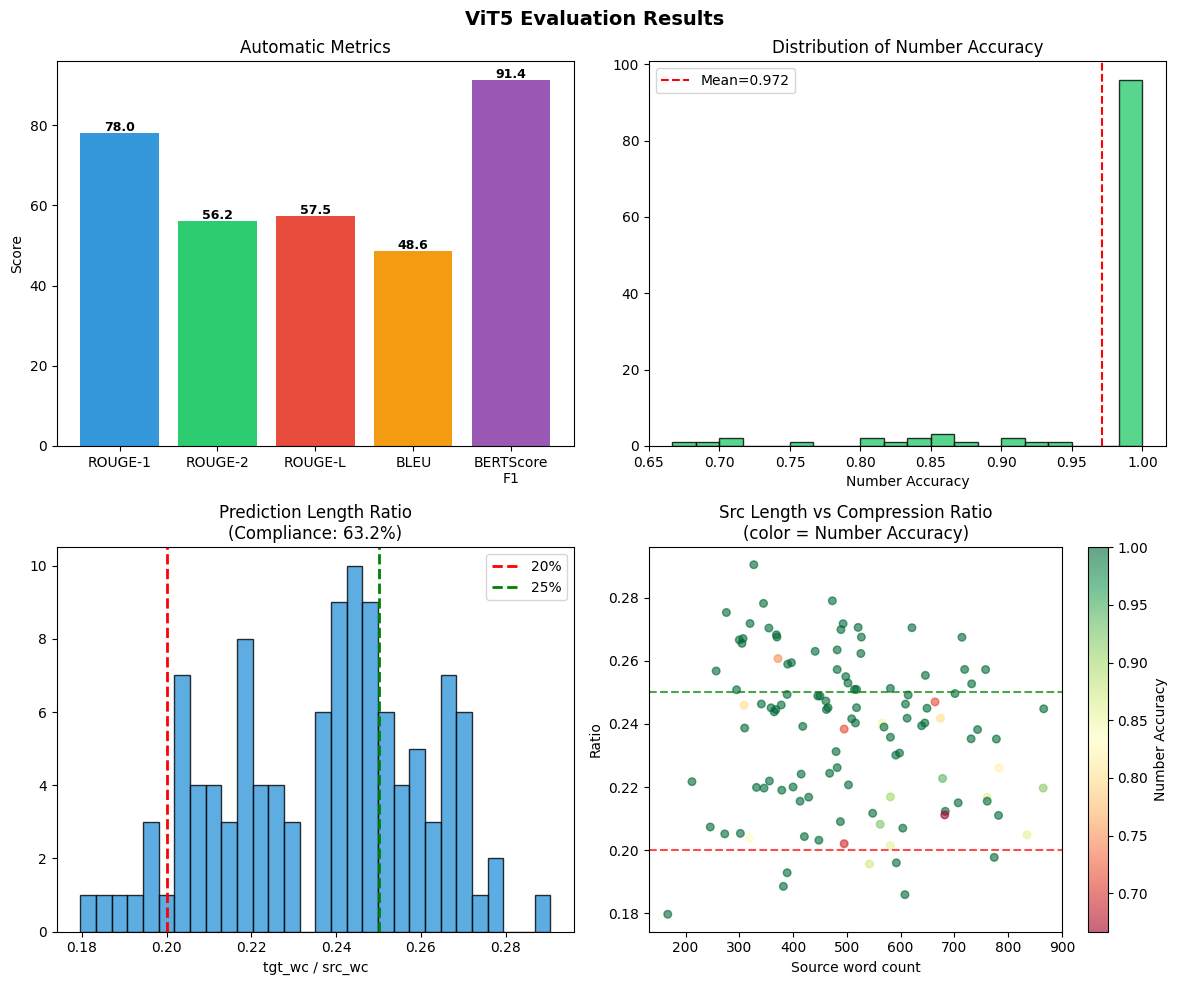

In [ ]:
# Visualize kết quả đánh giá
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ViT5 Evaluation Results', fontsize=14, fontweight='bold')

# Bar chart metrics
metric_names = ['ROUGE-1','ROUGE-2','ROUGE-L','BLEU','BERTScore\nF1']
metric_vals  = [
    rouge_results['rouge1']*100,
    rouge_results['rouge2']*100,
    rouge_results['rougeL']*100,
    bleu_result.score,
    F1.mean().item()*100
]
bars = axes[0,0].bar(metric_names, metric_vals, color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'])
axes[0,0].set_title('Automatic Metrics')
axes[0,0].set_ylabel('Score')
for bar, val in zip(bars, metric_vals):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

# Phân phối Number Accuracy
axes[0,1].hist(num_accuracy_scores, bins=20, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0,1].axvline(np.mean(num_accuracy_scores), color='r', ls='--', label=f'Mean={np.mean(num_accuracy_scores):.3f}')
axes[0,1].set_title('Distribution of Number Accuracy')
axes[0,1].set_xlabel('Number Accuracy')
axes[0,1].legend()

# Phân phối ratio prediction
pred_ratios = results_df['ratio']
axes[1,0].hist(pred_ratios, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[1,0].axvline(0.20, color='r', ls='--', lw=2, label='20%')
axes[1,0].axvline(0.25, color='g', ls='--', lw=2, label='25%')
axes[1,0].set_title(f'Prediction Length Ratio\n(Compliance: {np.mean(length_ok)*100:.1f}%)')
axes[1,0].set_xlabel('tgt_wc / src_wc')
axes[1,0].legend()

# Scatter: src length vs pred ratio
sc = axes[1,1].scatter(results_df['src_wc'], results_df['ratio'],
                        c=results_df['number_accuracy'], cmap='RdYlGn', alpha=0.6, s=30)
axes[1,1].axhline(0.20, color='r', ls='--', alpha=0.7)
axes[1,1].axhline(0.25, color='g', ls='--', alpha=0.7)
axes[1,1].set_title('Src Length vs Compression Ratio\n(color = Number Accuracy)')
axes[1,1].set_xlabel('Source word count')
axes[1,1].set_ylabel('Ratio')
plt.colorbar(sc, ax=axes[1,1], label='Number Accuracy')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eval_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Reinforcement Learning bổ sung cho ViT5-base

Phần này dùng mô hình `best_model` đã fine-tune supervised làm policy ban đầu, sau đó tinh chỉnh thêm bằng Reinforcement Learning theo hướng **Self-Critical Sequence Training (SCST)**.

**Reward dùng trong notebook:**
- `ROUGE-L`: đo mức gần với bản tóm tắt tham chiếu.
- `Number Accuracy`: chỉ phạt khi summary sinh ra số không có trong original text; thiếu số không bị phạt.
- `Length Compliance`: thưởng nếu độ dài summary nằm trong khoảng 20–25% so với original text.

Mặc định RL chạy ít bước để phù hợp Colab Free. Bạn có thể tăng `MAX_RL_STEPS` nếu còn thời gian/GPU.


In [ ]:
# ============================================================
# 7.1. LOAD MODEL SUPERVISED TỐT NHẤT ĐỂ REINFORCEMENT LEARNING
# ============================================================
import os, json, math, random, re
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

RL_BASE_MODEL_PATH = f'{OUTPUT_DIR}/best_model'
RL_OUTPUT_DIR      = f'{OUTPUT_DIR}/vit5_rl_model'
os.makedirs(RL_OUTPUT_DIR, exist_ok=True)

if not os.path.exists(RL_BASE_MODEL_PATH):
    raise FileNotFoundError(
        f'Không tìm thấy supervised best_model tại {RL_BASE_MODEL_PATH}. '
        'Bạn cần chạy fine-tuning supervised trước, hoặc kiểm tra lại OUTPUT_DIR.'
    )

print('📌 Load ViT5 supervised best_model để RL:')
print(RL_BASE_MODEL_PATH)

rl_tokenizer = T5Tokenizer.from_pretrained(RL_BASE_MODEL_PATH, legacy=True)
rl_model = T5ForConditionalGeneration.from_pretrained(RL_BASE_MODEL_PATH).to(device)
rl_model.train()

print('✅ Đã load model để Reinforcement Learning.')
print('Device:', device)
print('RL output:', RL_OUTPUT_DIR)


📌 Load ViT5 supervised best_model để RL:
/content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/best_model


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ Đã load model để Reinforcement Learning.
Device: cuda
RL output: /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/vit5_rl_model


In [ ]:
# ============================================================
# 7.2. REWARD FUNCTION CHO REINFORCEMENT LEARNING
# Reward = 35% ROUGE-L + 45% Number Accuracy + 20% Length Compliance
# ============================================================

def lcs_length(a, b):
    """Longest Common Subsequence length theo token."""
    m, n = len(a), len(b)
    if m == 0 or n == 0:
        return 0
    dp = [0] * (n + 1)
    for i in range(1, m + 1):
        prev = 0
        for j in range(1, n + 1):
            temp = dp[j]
            if a[i - 1] == b[j - 1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = temp
    return dp[n]


def rouge_l_f1_simple(prediction, reference):
    """ROUGE-L F1 đơn giản, đủ dùng cho reward trong RL."""
    pred_tokens = str(prediction).split()
    ref_tokens  = str(reference).split()
    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    lcs = lcs_length(pred_tokens, ref_tokens)
    precision = lcs / max(len(pred_tokens), 1)
    recall    = lcs / max(len(ref_tokens), 1)
    if precision + recall == 0:
        return 0.0
    return float(2 * precision * recall / (precision + recall))


def length_compliance_reward(source, summary, min_ratio=0.20, max_ratio=0.25):
    """
    Thưởng 1.0 nếu summary nằm trong 20–25% độ dài original_text.
    Nếu ngoài khoảng thì phạt mềm theo độ lệch.
    """
    src_wc = word_count(source)
    sum_wc = word_count(summary)
    if src_wc == 0:
        return 0.0

    ratio = sum_wc / src_wc
    if min_ratio <= ratio <= max_ratio:
        return 1.0
    if ratio < min_ratio:
        return max(0.0, ratio / min_ratio)
    return max(0.0, max_ratio / ratio)


def compute_rl_reward(source, prediction, reference):
    """
    Reward ưu tiên đúng yêu cầu đề:
    - ROUGE-L: chất lượng nội dung.
    - Number Accuracy: số trong summary phải có trong original_text.
    - Length Compliance: summary dài 20–25% original_text.
    """
    r_rouge = rouge_l_f1_simple(prediction, reference)

    # number_accuracy_rate trong notebook có thể trả về 2 hoặc 3 giá trị
    # tùy cell demo/đánh giá được chạy trước đó. Đoạn này xử lý cả hai trường hợp.
    num_result = number_accuracy_rate(source, prediction)
    if isinstance(num_result, tuple) and len(num_result) == 3:
        r_num, _, hallucinated = num_result
    elif isinstance(num_result, tuple) and len(num_result) == 2:
        r_num, hallucinated = num_result
    else:
        r_num = float(num_result)
        hallucinated = set()

    r_len = length_compliance_reward(source, prediction)

    # Ưu tiên Number Accuracy cao hơn vì đề yêu cầu giữ chính xác số liệu.
    reward = 0.35 * r_rouge + 0.45 * r_num + 0.20 * r_len

    return float(reward), {
        'rouge_l': float(r_rouge),
        'number_accuracy': float(r_num),
        'length_compliance': float(r_len),
        'wrong_numbers': sorted(list(hallucinated))
    }

print('✅ Đã định nghĩa reward function cho RL.')


✅ Đã định nghĩa reward function cho RL.


In [ ]:
# ============================================================
# 7.3. DATASET CHO RL
# ============================================================

class RLSummarizationDataset(Dataset):
    def __init__(self, dataframe, source_col='original_text', target_col='summary'):
        self.df = dataframe[[source_col, target_col]].dropna().reset_index(drop=True)
        self.source_col = source_col
        self.target_col = target_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            'source': str(row[self.source_col]),
            'reference': str(row[self.target_col])
        }

# Colab Free: nên RL trên một phần train trước để nhanh và an toàn.
# Nếu muốn dùng toàn bộ train, đặt RL_TRAIN_MAX_SAMPLES = len(train_df).
RL_TRAIN_MAX_SAMPLES = min(300, len(train_df))
RL_BATCH_SIZE = 1  # batch 1 ổn định hơn cho generate + policy gradient trên T4

rl_train_df = train_df.sample(RL_TRAIN_MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
rl_dataset = RLSummarizationDataset(rl_train_df)
rl_loader = DataLoader(rl_dataset, batch_size=RL_BATCH_SIZE, shuffle=True)

print('✅ Số mẫu train dùng cho RL:', len(rl_dataset))
print('✅ RL batch size:', RL_BATCH_SIZE)


✅ Số mẫu train dùng cho RL: 300
✅ RL batch size: 1


In [ ]:
# ============================================================
# 7.4. HÀM GENERATE VÀ TÍNH LOG PROBABILITY CHO POLICY GRADIENT
# ============================================================

RL_MAX_INPUT_LEN  = MAX_INPUT_LEN
RL_MAX_TARGET_LEN = MAX_TARGET_LEN
RL_PREFIX         = PREFIX


def generate_sampled_summary(model, tokenizer, sources):
    """Sinh summary bằng sampling để cập nhật policy."""
    model.eval()
    inputs = tokenizer(
        [RL_PREFIX + str(s) for s in sources],
        max_length=RL_MAX_INPUT_LEN,
        truncation=True,
        padding=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_length=RL_MAX_TARGET_LEN,
            min_length=30,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=1.0,
            no_repeat_ngram_size=3,
            early_stopping=True,
            forced_eos_token_id=tokenizer.eos_token_id
        )

    summaries = tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )
    model.train()
    return generated_ids, summaries, inputs


def generate_baseline_summary(model, tokenizer, sources):
    """Sinh baseline bằng beam search để tính advantage theo SCST."""
    model.eval()
    inputs = tokenizer(
        [RL_PREFIX + str(s) for s in sources],
        max_length=RL_MAX_INPUT_LEN,
        truncation=True,
        padding=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_length=RL_MAX_TARGET_LEN,
            min_length=30,
            num_beams=4,
            no_repeat_ngram_size=3,
            early_stopping=True,
            forced_eos_token_id=tokenizer.eos_token_id
        )

    summaries = tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )
    model.train()
    return summaries


def sequence_log_probability(model, input_ids, attention_mask, generated_ids, pad_token_id):
    """
    Tính log probability trung bình của chuỗi generated_ids.
    Đây là thành phần log pi(a|s) trong REINFORCE.
    """
    labels = generated_ids.clone()
    labels[labels == pad_token_id] = -100

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    logits = outputs.logits
    log_probs = torch.log_softmax(logits, dim=-1)

    target_ids = labels.clone()
    target_ids[target_ids == -100] = pad_token_id

    token_log_probs = log_probs.gather(
        dim=-1,
        index=target_ids.unsqueeze(-1)
    ).squeeze(-1)

    mask = (labels != -100).float()
    seq_log_probs = (token_log_probs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return seq_log_probs

print('✅ Đã chuẩn bị hàm generate/logprob cho RL.')


✅ Đã chuẩn bị hàm generate/logprob cho RL.


In [ ]:
# ============================================================
# 7.5. TRAIN REINFORCEMENT LEARNING — SCST / REINFORCE
# ============================================================

RL_EPOCHS = 1
RL_LR = 1e-6
MAX_RL_STEPS = 500   # Tăng lên 300–500 nếu còn thời gian/GPU

optimizer = torch.optim.AdamW(rl_model.parameters(), lr=RL_LR)
rl_model.train()

rl_logs = []
global_step = 0

print('🚀 Bắt đầu Reinforcement Learning cho ViT5-base...')
print(f'RL_EPOCHS={RL_EPOCHS}, MAX_RL_STEPS={MAX_RL_STEPS}, LR={RL_LR}')

for epoch in range(RL_EPOCHS):
    progress_bar = tqdm(rl_loader, desc=f'RL Epoch {epoch+1}/{RL_EPOCHS}')

    for batch in progress_bar:
        sources_batch = list(batch['source'])
        refs_batch    = list(batch['reference'])

        # 1) Summary sampled từ policy hiện tại
        sampled_ids, sampled_summaries, inputs = generate_sampled_summary(
            rl_model, rl_tokenizer, sources_batch
        )

        # 2) Summary baseline bằng beam search
        baseline_summaries = generate_baseline_summary(
            rl_model, rl_tokenizer, sources_batch
        )

        # 3) Reward sampled và baseline
        sampled_rewards = []
        baseline_rewards = []
        detail_rewards = []

        for src, pred, base_pred, ref in zip(
            sources_batch, sampled_summaries, baseline_summaries, refs_batch
        ):
            sampled_reward, sampled_detail = compute_rl_reward(src, pred, ref)
            baseline_reward, _ = compute_rl_reward(src, base_pred, ref)
            sampled_rewards.append(sampled_reward)
            baseline_rewards.append(baseline_reward)
            detail_rewards.append(sampled_detail)

        sampled_rewards_t = torch.tensor(sampled_rewards, dtype=torch.float32, device=device)
        baseline_rewards_t = torch.tensor(baseline_rewards, dtype=torch.float32, device=device)
        advantages = sampled_rewards_t - baseline_rewards_t

        # 4) Log probability của sampled summary
        seq_log_probs = sequence_log_probability(
            rl_model,
            inputs['input_ids'],
            inputs['attention_mask'],
            sampled_ids,
            rl_tokenizer.pad_token_id
        )

        # 5) Policy gradient loss
        loss = -(advantages.detach() * seq_log_probs).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rl_model.parameters(), 1.0)
        optimizer.step()

        global_step += 1

        log_item = {
            'step': global_step,
            'loss': float(loss.item()),
            'sampled_reward': float(sampled_rewards_t.mean().item()),
            'baseline_reward': float(baseline_rewards_t.mean().item()),
            'advantage': float(advantages.mean().item()),
            'rouge_l': float(np.mean([d['rouge_l'] for d in detail_rewards])),
            'number_accuracy': float(np.mean([d['number_accuracy'] for d in detail_rewards])),
            'length_compliance_reward': float(np.mean([d['length_compliance'] for d in detail_rewards]))
        }
        rl_logs.append(log_item)

        progress_bar.set_postfix({
            'loss': round(log_item['loss'], 4),
            'reward': round(log_item['sampled_reward'], 4),
            'adv': round(log_item['advantage'], 4),
            'num_acc': round(log_item['number_accuracy'], 3)
        })

        if global_step >= MAX_RL_STEPS:
            break

    if global_step >= MAX_RL_STEPS:
        break

print('✅ Hoàn tất RL training.')
print('Tổng RL steps:', global_step)


🚀 Bắt đầu Reinforcement Learning cho ViT5-base...
RL_EPOCHS=1, MAX_RL_STEPS=500, LR=1e-06


RL Epoch 1/1:   0%|          | 0/300 [00:00<?, ?it/s]

✅ Hoàn tất RL training.
Tổng RL steps: 300


In [ ]:
# ============================================================
# 7.6. LƯU MODEL SAU REINFORCEMENT LEARNING
# ============================================================

os.makedirs(RL_OUTPUT_DIR, exist_ok=True)
rl_model.save_pretrained(RL_OUTPUT_DIR)
rl_tokenizer.save_pretrained(RL_OUTPUT_DIR)

rl_log_df = pd.DataFrame(rl_logs)
rl_log_path = f'{RL_OUTPUT_DIR}/rl_training_logs.csv'
rl_log_df.to_csv(rl_log_path, index=False, encoding='utf-8-sig')

print('✅ Đã lưu ViT5 + RL tại:')
print(RL_OUTPUT_DIR)
print('✅ Đã lưu log RL tại:')
print(rl_log_path)

if len(rl_log_df) > 0:
    display(rl_log_df.tail())


✅ Đã lưu ViT5 + RL tại:
/content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/vit5_rl_model
✅ Đã lưu log RL tại:
/content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/vit5_rl_model/rl_training_logs.csv


,step,loss,sampled_reward,baseline_reward,advantage,rouge_l,number_accuracy,length_compliance_reward
295,296,0.008745,0.724375,0.693696,0.030679,0.212500,1.00,1.000000
296,297,-0.004253,0.820129,0.835203,-0.015073,0.525680,1.00,0.930707
297,298,-0.013803,0.894714,1.000000,-0.105286,0.751131,1.00,0.909091
298,299,-0.027103,0.764229,0.831481,-0.067252,0.709957,0.75,0.891221
299,300,0.013327,0.866355,0.832284,0.034072,0.773723,1.00,0.727763


In [ ]:
# ============================================================
# FIX HÀM NUMBER ACCURACY CHO ĐÁNH GIÁ RL
# Đảm bảo number_accuracy_rate luôn trả về 3 giá trị:
# accuracy, missing, hallucinated
# ============================================================

import re

def extract_numbers(text):
    text = str(text)
    pattern = r"""
        \d{1,2}/\d{1,2}(?:/\d{2,4})?
        |
        \d+(?:[.,]\d+)*%?
    """
    nums = re.findall(pattern, text, flags=re.VERBOSE)
    return set([n.strip() for n in nums if n.strip()])


def number_accuracy_rate(src, tgt):
    """
    Number Accuracy:
    - Chỉ xét số xuất hiện trong summary/prediction.
    - Nếu số trong summary có trong original_text => đúng.
    - Nếu summary thiếu số từ original_text => không phạt.
    - Chỉ phạt số trong summary nhưng không có trong original_text.

    Return:
    - accuracy
    - missing: số có trong original_text nhưng thiếu trong summary, chỉ để tham khảo
    - hallucinated: số trong summary nhưng không có trong original_text
    """
    src_nums = extract_numbers(src)
    tgt_nums = extract_numbers(tgt)

    missing = src_nums - tgt_nums
    hallucinated = tgt_nums - src_nums

    if len(tgt_nums) == 0:
        return 1.0, missing, hallucinated

    correct_nums = tgt_nums & src_nums
    accuracy = len(correct_nums) / len(tgt_nums)

    return accuracy, missing, hallucinated


print("✅ Đã fix number_accuracy_rate: hàm hiện trả về 3 giá trị.")

✅ Đã fix number_accuracy_rate: hàm hiện trả về 3 giá trị.


In [ ]:
# ============================================================
# 7.7. ĐÁNH GIÁ MODEL SAU RL TRÊN TẬP TEST
# ============================================================

print('📌 Load model sau RL để đánh giá:')
print(RL_OUTPUT_DIR)

rl_eval_tokenizer = T5Tokenizer.from_pretrained(RL_OUTPUT_DIR, legacy=True)
rl_eval_model = T5ForConditionalGeneration.from_pretrained(RL_OUTPUT_DIR).to(device)
rl_eval_model.eval()

rl_predictions = []
rl_references = test_df['summary'].tolist()
rl_sources = test_df['original_text'].tolist()

print(f'⏳ Đang generate {len(rl_sources)} tóm tắt bằng ViT5 + RL...')
for i, src in enumerate(rl_sources):
    src_wc = word_count(src)
    pred = generate_summary_constrained(
        src,
        rl_eval_model,
        rl_eval_tokenizer,
        src_wc
    )
    rl_predictions.append(pred)
    if (i + 1) % 20 == 0:
        print(f'  Đã generate {i+1}/{len(rl_sources)}')

print('📊 Đang tính ROUGE cho ViT5 + RL...')
rouge = evaluate.load('rouge')
rouge_results_rl = rouge.compute(
    predictions=rl_predictions,
    references=rl_references,
    use_stemmer=False
)

print('📊 Đang tính BLEU cho ViT5 + RL...')
bleu_result_rl = sacrebleu.corpus_bleu(rl_predictions, [rl_references])

print('📊 Đang tính BERTScore cho ViT5 + RL...')
P_rl, R_rl, F1_rl = bert_score_fn(
    rl_predictions,
    rl_references,
    lang='vi',
    model_type='xlm-roberta-base',
    verbose=False
)

print('📊 Đang tính Number Accuracy & Length Compliance cho ViT5 + RL...')
rl_num_accuracy_scores = []
rl_length_ok = []
rl_hallucinated_counts = []

for pred, src in zip(rl_predictions, rl_sources):
    src_wc = word_count(src)
    pred_wc = word_count(pred)
    ratio = pred_wc / src_wc if src_wc > 0 else 0
    rl_length_ok.append(0.20 <= ratio <= 0.25)

    acc, missing, hallucinated = number_accuracy_rate(src, pred)
    rl_num_accuracy_scores.append(acc)
    rl_hallucinated_counts.append(len(hallucinated))

print('\n' + '='*60)
print('        EVALUATION RESULTS — ViT5-base + RL')
print('='*60)
print(f"  ROUGE-1          : {rouge_results_rl['rouge1']*100:.2f}")
print(f"  ROUGE-2          : {rouge_results_rl['rouge2']*100:.2f}")
print(f"  ROUGE-L          : {rouge_results_rl['rougeL']*100:.2f}")
print(f"  BLEU             : {bleu_result_rl.score:.2f}")
print(f"  BERTScore F1     : {F1_rl.mean().item()*100:.2f}")
print(f"  Number Accuracy  : {np.mean(rl_num_accuracy_scores)*100:.2f}")
print(f"  Length Compliance: {np.mean(rl_length_ok)*100:.2f}%")
print(f"  Avg wrong nums   : {np.mean(rl_hallucinated_counts):.2f} per sample")
print('='*60)

rl_eval_results = {
    'model':              'VietAI/vit5-base + RL',
    'RL-method':          'SCST/REINFORCE',
    'reward':             '0.35*ROUGE-L + 0.45*NumberAccuracy + 0.20*LengthCompliance',
    'ROUGE-1':            round(rouge_results_rl['rouge1']*100, 4),
    'ROUGE-2':            round(rouge_results_rl['rouge2']*100, 4),
    'ROUGE-L':            round(rouge_results_rl['rougeL']*100, 4),
    'BLEU':               round(bleu_result_rl.score, 4),
    'BERTScore-F1':       round(F1_rl.mean().item()*100, 4),
    'Number-Accuracy':    round(np.mean(rl_num_accuracy_scores)*100, 4),
    'Length-Compliance':  round(np.mean(rl_length_ok)*100, 4),
    'Avg-Wrong-Numbers':  round(np.mean(rl_hallucinated_counts), 4)
}

with open(f'{RL_OUTPUT_DIR}/eval_results_vit5_rl.json', 'w', encoding='utf-8') as f:
    json.dump(rl_eval_results, f, ensure_ascii=False, indent=2)

rl_results_df = pd.DataFrame({
    'original_text': rl_sources,
    'reference': rl_references,
    'prediction_rl': rl_predictions,
    'src_wc': [word_count(s) for s in rl_sources],
    'pred_wc': [word_count(p) for p in rl_predictions],
    'ratio': [word_count(p)/word_count(s) if word_count(s)>0 else 0 for p, s in zip(rl_predictions, rl_sources)],
    'number_accuracy': rl_num_accuracy_scores,
    'wrong_num_count': rl_hallucinated_counts,
    'length_ok': rl_length_ok
})
rl_results_df.to_csv(f'{RL_OUTPUT_DIR}/test_predictions_vit5_rl.csv', index=False, encoding='utf-8-sig')

print(f'✅ Đã lưu kết quả RL tại: {RL_OUTPUT_DIR}')


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


📌 Load model sau RL để đánh giá:
/content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/vit5_rl_model
⏳ Đang generate 114 tóm tắt bằng ViT5 + RL...
  Đã generate 20/114
  Đã generate 40/114
  Đã generate 60/114
  Đã generate 80/114
  Đã generate 100/114
📊 Đang tính ROUGE cho ViT5 + RL...
📊 Đang tính BLEU cho ViT5 + RL...
📊 Đang tính BERTScore cho ViT5 + RL...
📊 Đang tính Number Accuracy & Length Compliance cho ViT5 + RL...

        EVALUATION RESULTS — ViT5-base + RL
  ROUGE-1          : 77.99
  ROUGE-2          : 56.77
  ROUGE-L          : 58.67
  BLEU             : 49.90
  BERTScore F1     : 91.48
  Number Accuracy  : 96.46
  Length Compliance: 57.89%
  Avg wrong nums   : 0.40 per sample
✅ Đã lưu kết quả RL tại: /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/vit5_rl_model


In [ ]:
# ============================================================
# 7.8. SO SÁNH NHANH SUPERVISED vs RL
# ============================================================

base_eval_path = f'{OUTPUT_DIR}/eval_results.json'
rl_eval_path = f'{RL_OUTPUT_DIR}/eval_results_vit5_rl.json'

if os.path.exists(base_eval_path) and os.path.exists(rl_eval_path):
    with open(base_eval_path, 'r', encoding='utf-8') as f:
        base_eval = json.load(f)
    with open(rl_eval_path, 'r', encoding='utf-8') as f:
        rl_eval = json.load(f)

    compare_df = pd.DataFrame([
        {'model': 'ViT5 supervised', **base_eval},
        {'model': 'ViT5 + RL', **rl_eval}
    ])

    cols = ['model', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'BERTScore-F1',
            'Number-Accuracy', 'Length-Compliance', 'Avg-Wrong-Numbers']
    cols = [c for c in cols if c in compare_df.columns]
    display(compare_df[cols])

    compare_df.to_csv(f'{OUTPUT_DIR}/compare_supervised_vs_rl.csv', index=False, encoding='utf-8-sig')
    print(f'✅ Đã lưu bảng so sánh tại: {OUTPUT_DIR}/compare_supervised_vs_rl.csv')
else:
    print('ℹ️ Chưa đủ file eval_results để so sánh. Hãy chạy cell đánh giá supervised và đánh giá RL trước.')


,model,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,BERTScore-F1,Number-Accuracy,Length-Compliance,Avg-Wrong-Numbers
0,VietAI/vit5-base,77.9778,56.1664,57.4595,48.6265,91.3713,97.1569,63.1579,0.2632
1,VietAI/vit5-base + RL,77.9919,56.7750,58.6713,49.8961,91.4823,96.4563,57.8947,0.4035


✅ Đã lưu bảng so sánh tại: /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/compare_supervised_vs_rl.csv


## 7. Inference & Demo

In [ ]:
def demo_summarize(text, verbose=True):
    """
    Demo đầy đủ: sinh tóm tắt + kiểm tra số liệu + thống kê.
    Number Accuracy: số xuất hiện trong summary phải có trong original_text;
    thiếu số trong original_text không bị tính là lỗi.
    """
    src_wc = word_count(text)
    summary = generate_summary_constrained(
        text, eval_model, eval_tokenizer, src_wc
    )
    summary, missing, hallucinated = postprocess_check_numbers(text, summary)
    number_acc, _, _ = number_accuracy_rate(text, summary)

    pred_wc = word_count(summary)
    ratio   = pred_wc / src_wc

    if verbose:
        print('=' * 60)
        print('📄 VĂN BẢN GỐC:')
        print(text[:500] + ('...' if len(text) > 500 else ''))
        print('\n📝 BẢN TÓM TẮT:')
        print(summary)
        print('\n📊 THỐNG KÊ:')
        print(f'   Độ dài gốc       : {src_wc} từ')
        print(f'   Độ dài tóm tắt   : {pred_wc} từ')
        print(f'   Tỉ lệ nén        : {ratio:.2%} ', end='')
        print('✅' if 0.20 <= ratio <= 0.25 else '⚠️ Ngoài 20-25%')
        print(f'   Độ chính xác số liệu: {number_acc:.2%}')
        if hallucinated:
            print(f'   ⚠️ Số liệu sai/ảo giác: {hallucinated}')
        else:
            print('   ✅ Số liệu: 100% số trong summary đều có trong văn bản gốc')
        print('=' * 60)

    return summary

# Thử với 3 mẫu từ tập test
print('=== DEMO 3 MẪU TỪ TẬP TEST ===\n')
for i in range(min(3, len(test_df))):
    print(f'\n--- Mẫu {i+1} ---')
    _ = demo_summarize(test_df['original_text'].iloc[i])


=== DEMO 3 MẪU TỪ TẬP TEST ===


--- Mẫu 1 ---
📄 VĂN BẢN GỐC:
Tiêu đề: Đà Nẵng đấu giá khu đất làm tổ hợp phục vụ Lễ hội pháo hoa quốc tế
Nội dung: UBND thành phố vừa ban hành quyết định tổ chức đấu giá quyền sử dụng đất dự án Tổ hợp công trình phục vụ Lễ hội pháo hoa quốc tế Đà Nẵng tại phường Ngũ Hành Sơn. Dự án có quy mô hơn 210.000 m2, trong đó phần diện tích đưa ra đấu giá là 48.000 m2. Khu vực này bao gồm các khu chức năng: A3, A6, A7, A8 và khu SK. Mức giá khởi điểm được xác định là 36,428 triệu đồng/m2, tiền đặt trước để tham gia đấu giá là hơn 350...

📝 BẢN TÓM TẮT:
UBND thành phố vừa ban hành quyết định tổ chức đấu giá quyền sử dụng đất dự án Tổ hợp công trình phục vụ Lễ hội pháo hoa quốc tế Đà Nẵng tại phường Ngũ Hành Sơn. Mức giá khởi điểm được xác định là 36,428 triệu đồng/m2, tiền đặt trước để tham gia đấu giá là hơn 350 tỷ đồng. Đến năm 2017, sự kiện này đổi tên thành "Lễ hội" và chuyển sang hình thức xã hội hóa hoàn toàn. Năm nay, lễ hội diễn ra từ ngày 30/5 đến 11/7.



In [ ]:
# Thử với văn bản tùy ý
custom_text = """
Nhập văn bản của bạn vào đây để thử nghiệm...
"""

if len(custom_text.strip()) > 50:
    _ = demo_summarize(custom_text)
else:
    print('ℹ️  Thay custom_text bằng văn bản thực tế để test!')

## 8. Lưu model & Tổng kết

In [ ]:
# Lưu training config để tái sản xuất
config = {
    'model_name':       MODEL_NAME,
    'max_input_len':    MAX_INPUT_LEN,
    'max_target_len':   MAX_TARGET_LEN,
    'prefix':           PREFIX,
    'batch_size':       BATCH_SIZE,
    'grad_accum':       GRAD_ACCUM,
    'effective_batch':  BATCH_SIZE * GRAD_ACCUM,
    'num_epochs':       NUM_EPOCHS,
    'learning_rate':    LEARNING_RATE,
    'warmup_steps':     WARMUP_STEPS,
    'weight_decay':     WEIGHT_DECAY,
    'num_beams':        NUM_BEAMS,
    'length_penalty':   LENGTH_PENALTY,
    'no_repeat_ngram':  NO_REPEAT_NGRAM,
    'seed':             SEED
}

with open(f'{OUTPUT_DIR}/training_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print('✅ Đã lưu tất cả kết quả:')
print(f'   {OUTPUT_DIR}/')
print(f'   ├── best_model/          (model + tokenizer)')
print(f'   ├── checkpoints/         (checkpoints theo epoch)')
print(f'   ├── eval_results.json    (tất cả metrics)')
print(f'   ├── test_predictions.csv (predictions vs references)')
print(f'   ├── training_config.json (hyperparameters)')
print(f'   ├── eda_stats.png')
print(f'   ├── training_history.png')
print(f'   └── eval_visualizations.png')

print('\n📊 KẾT QUẢ CUỐI CÙNG:')
for k, v in eval_results.items():
    print(f'   {k:<25}: {v}')

✅ Đã lưu tất cả kết quả:
   /content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/
   ├── best_model/          (model + tokenizer)
   ├── checkpoints/         (checkpoints theo epoch)
   ├── eval_results.json    (tất cả metrics)
   ├── test_predictions.csv (predictions vs references)
   ├── training_config.json (hyperparameters)
   ├── eda_stats.png
   ├── training_history.png
   └── eval_visualizations.png

📊 KẾT QUẢ CUỐI CÙNG:
   model                    : VietAI/vit5-base
   ROUGE-1                  : 77.9778
   ROUGE-2                  : 56.1664
   ROUGE-L                  : 57.4595
   BLEU                     : 48.6265
   BERTScore-F1             : 91.3713
   Number-Accuracy          : 97.1569
   Length-Compliance        : 63.1579
   Avg-Wrong-Numbers        : 0.2632


In [ ]:
# (Tuỳ chọn) Upload lên HuggingFace Hub
# from huggingface_hub import notebook_login
# notebook_login()
# eval_model.push_to_hub('your-username/vit5-vietnamese-summarization')
# eval_tokenizer.push_to_hub('your-username/vit5-vietnamese-summarization')
print('💡 Bỏ comment phần trên nếu muốn push lên HuggingFace Hub!')

In [ ]:
!pip install -q huggingface_hub transformers sentencepiece

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import T5Tokenizer, T5ForConditionalGeneration

best_model_path = "/content/drive/MyDrive/NLP_FINAL/VIT5_OUTPUT/best_model"

tokenizer = T5Tokenizer.from_pretrained(best_model_path, legacy=True)
model = T5ForConditionalGeneration.from_pretrained(best_model_path)

repo_id = "tranthaomy901/vit5-vietnamese-summarization"

model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...thacg3r/model.safetensors:   4%|4         | 40.0MB /  904MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../tmp8ix4_a5g/spiece.model: 100%|##########|  820kB /  820kB            

CommitInfo(commit_url='https://huggingface.co/tranthaomy901/vit5-vietnamese-summarization/commit/7869cb0d4a5f4287c406c2db82696f708fe0f0ff', commit_message='Upload tokenizer', commit_description='', oid='7869cb0d4a5f4287c406c2db82696f708fe0f0ff', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tranthaomy901/vit5-vietnamese-summarization', endpoint='https://huggingface.co', repo_type='model', repo_id='tranthaomy901/vit5-vietnamese-summarization'), pr_revision=None, pr_num=None)